# Importación de Librerías

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de Datos

In [171]:
df = pd.read_csv('ferreteria_COSTOS_ventas_2024.csv')
df.head(10)

,fecha,producto,tipo_producto,marca,categoria,cantidad,precio_unitario,precio_total,metodo_pago,comprobante
0,2024-01-02,grava,NaN,Ladrillera Virú,material_construccion,3.0,36.86,110.58,yape,boleta
1,2024-01-02,tuercas_arandelas,hexagonal,Fijesa,fijacion,46.0,0.85,39.1,tarjeta,boleta
2,2024-01-02,ladrillo,Pandereta,Cerámica Lark,material_construccion,2641.0,2.08,5493.28,efectivo,factura
3,2024-01-02,fierro_corrugado,1/2,Aceros Arequipa,material_construccion,10.0,35.97,359.7,efectivo,NaN
4,2024-01-02,cintillos,plastico 200mm,Truper,fijacion,37.0,0.29,10.73,tarjeta,factura
5,2024-01-02,ladrillo,King Kong,Ladrillera Virú,material_construccion,2036.0,2.42,4927.12,tarjeta,boleta
6,2024-01-02,escalera,aluminio 3m,Bailey,accesorios,2.0,143.7,287.4,efectivo,factura
7,2024-01-02,brocha,rodillo,Truper,pinturas,1.0,11.27,11.27,efectivo,boleta
8,2024-01-02,pintura,NaN,Zinsser,pinturas,2.0,81.39,162.78,efectivo,boleta
9,2024-01-02,rodillo,grande,Pintuco,pinturas,1.0,41.43,41.43,plin,boleta


# **Exploración de los datos**

In [172]:
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (24720, 10)


In [173]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24720 entries, 0 to 24719
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha            23996 non-null  object
 1   producto         23975 non-null  object
 2   tipo_producto    23995 non-null  object
 3   marca            23957 non-null  object
 4   categoria        24019 non-null  object
 5   cantidad         23951 non-null  object
 6   precio_unitario  23933 non-null  object
 7   precio_total     23914 non-null  object
 8   metodo_pago      24036 non-null  object
 9   comprobante      23954 non-null  object
dtypes: object(10)
memory usage: 1.9+ MB


In [174]:
# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
fecha              724
producto           745
tipo_producto      725
marca              763
categoria          701
cantidad           769
precio_unitario    787
precio_total       806
metodo_pago        684
comprobante        766
dtype: int64


In [175]:
# Detección de registros duplicados
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")
# Porcentaje de duplicados
print(f"\nPorcentaje de Registros duplicados: ({duplicados/len(df)*100:.2f}%)")

Registros duplicados: 681

Porcentaje de Registros duplicados: (2.75%)


In [176]:
# Análisis estadístico general
df.describe(include='all').T

,count,unique,top,freq
fecha,23996,354,2024-11-05,145
producto,23975,56,grava,2424
tipo_producto,23995,113,triturada,1220
marca,23957,52,Ladrillera Virú,5498
categoria,24019,8,material_construccion,13987
cantidad,23951,1507,1.0,6120
precio_unitario,23933,10358,--,66
precio_total,23914,17615,--,66
metodo_pago,24036,5,efectivo,8473
comprobante,23954,2,boleta,18695


In [177]:
# Muestra cuántas veces aparece cada valor único
conteo_valores = df['producto'].value_counts()
print(conteo_valores)

producto
grava                 2424
cemento               2337
arena                 2315
ladrillo              2305
fierro_corrugado      2263
adhesivo               771
pegamento_contacto     768
calamina               755
sellador               352
brocha                 342
disolvente             332
lija                   321
thinner                317
sellador_termico       315
rodillo                314
pintura                309
caja_placa             297
enchufe                296
interruptor            294
led_tira               283
foco_led               281
cable                  279
tomacorriente          251
grifos                 231
tuberia_pvc            228
valvula                222
tornillos              217
pernos_bulones         214
cintillos              211
cinta_teflon           209
clavos                 203
tuercas_arandelas      198
tarugos                185
sellador_silicon       166
malla_mosquitera       165
sierra_circular        163
aspersor_jardin    

# Conversión preliminar de tipos (solo para exploración)

In [178]:
# Conversión de tipos de datos
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce')
df['precio_unitario'] = pd.to_numeric(df['precio_unitario'], errors='coerce')
df['precio_total'] = pd.to_numeric(df['precio_total'], errors='coerce')

# Verificar nuevamente los tipos
df.dtypes

fecha              datetime64[ns]
producto                   object
tipo_producto              object
marca                      object
categoria                  object
cantidad                  float64
precio_unitario           float64
precio_total              float64
metodo_pago                object
comprobante                object
dtype: object

# Distribución por categoría de producto

In [179]:
categoria_counts = df['categoria'].value_counts()
print(categoria_counts)

categoria
material_construccion    13987
pinturas                  2607
electricidad              1953
herramientas              1901
fijacion                  1233
accesorios                1116
gasfiteria                 891
seguridad_industrial       331
Name: count, dtype: int64


# Análisis de comportamiento temporal

In [180]:
# Ventas totales por mes
ventas_mensuales = df.groupby(df['fecha'].dt.month)['precio_total'].sum()
ventas_mensuales

fecha
1.0      422411.24
2.0      488966.73
3.0      430358.69
4.0      380185.39
5.0      452191.85
6.0     1789694.89
7.0     1764837.28
8.0     1597992.16
9.0     1850054.98
10.0    1693077.25
11.0    1670926.84
12.0     476067.26
Name: precio_total, dtype: float64

# **PREPARACIÓN DE LOS DATOS**

# Procesos de Limpieza

In [181]:
# --- Conversión de tipos ---
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce')
df['precio_unitario'] = pd.to_numeric(df['precio_unitario'], errors='coerce')
df['precio_total'] = pd.to_numeric(df['precio_total'], errors='coerce')

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24720 entries, 0 to 24719
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            23996 non-null  datetime64[ns]
 1   producto         23975 non-null  object        
 2   tipo_producto    23995 non-null  object        
 3   marca            23957 non-null  object        
 4   categoria        24019 non-null  object        
 5   cantidad         23766 non-null  float64       
 6   precio_unitario  23742 non-null  float64       
 7   precio_total     23739 non-null  float64       
 8   metodo_pago      24036 non-null  object        
 9   comprobante      23954 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 1.9+ MB


In [183]:
# Eliminación de duplicados
antes = df.shape[0]
df = df.drop_duplicates()
despues = df.shape[0]
print(f"Duplicados eliminados: {antes - despues}")

Duplicados eliminados: 682


In [184]:
# Imputación de valores nulos
df['marca'] = df['marca'].fillna('Desconocida')
df['tipo_producto'] = df['tipo_producto'].fillna('No especificado')
df['categoria'] = df['categoria'].fillna('Sin categoría')

df['cantidad'] = df['cantidad'].fillna(df['cantidad'].median())
df['precio_unitario'] = df['precio_unitario'].fillna(df['precio_unitario'].median())
df['precio_total'] = df['precio_total'].fillna(df['precio_total'].median())

In [185]:
# Verificación
df.isnull().sum()

fecha              704
producto           722
tipo_producto        0
marca                0
categoria            0
cantidad             0
precio_unitario      0
precio_total         0
metodo_pago        664
comprobante        742
dtype: int64

# Normalización

In [186]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalización de variables numéricas
df[['cantidad_norm', 'precio_unitario_norm', 'precio_total_norm']] = scaler.fit_transform(
    df[['cantidad', 'precio_unitario', 'precio_total']]
)

# Verificar resultados
df[['cantidad_norm', 'precio_unitario_norm', 'precio_total_norm']].describe()

,cantidad_norm,precio_unitario_norm,precio_total_norm
count,24038.000000,24038.000000,24038.000000
mean,0.055744,0.039181,0.053837
std,0.184979,0.081364,0.120078
min,0.000000,0.000000,0.000000
25%,0.000334,0.013763,0.006799
50%,0.000667,0.021716,0.016019
75%,0.003670,0.037305,0.041036
max,1.000000,1.000000,1.000000


# Transformación

In [187]:
# Limpieza de texto: pasar todo a minúsculas y quitar espacios
cols_texto = ['producto', 'tipo_producto', 'marca', 'categoria', 'metodo_pago', 'comprobante']
for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Variables temporales derivadas
df['mes'] = df['fecha'].dt.month
df['año'] = df['fecha'].dt.year

# Día de la semana
df['dia_semana'] = df['fecha'].dt.day_name()
df['dia_semana'] = df['dia_semana'].replace({
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
})

# Validación
df[['fecha', 'mes', 'año', 'dia_semana']].head()

,fecha,mes,año,dia_semana
0,2024-01-02,1.0,2024.0,Martes
1,2024-01-02,1.0,2024.0,Martes
2,2024-01-02,1.0,2024.0,Martes
3,2024-01-02,1.0,2024.0,Martes
4,2024-01-02,1.0,2024.0,Martes


# Ingeniería de características

In [188]:
# Variable binaria: ¿pertenece a materiales de construcción?
df['es_construccion'] = np.where(df['categoria'].str.contains('construccion', case=False, na=False), 1, 0)

# Margen estimado
df['margen_estimado'] = df['precio_total'] * 0.30

# Variable binaria: alta demanda (por encima de la mediana de cantidad)
mediana_cant = df['cantidad'].median()
df['alta_demanda'] = np.where(df['cantidad'] > mediana_cant, 1, 0)

# Validar resultados
df[['producto', 'categoria', 'cantidad', 'es_construccion', 'margen_estimado', 'alta_demanda']].head()

,producto,categoria,cantidad,es_construccion,margen_estimado,alta_demanda
0,grava,material_construccion,3.0,1,33.174,0
1,tuercas_arandelas,fijacion,46.0,0,11.730,1
2,ladrillo,material_construccion,2641.0,1,1647.984,1
3,fierro_corrugado,material_construccion,10.0,1,107.910,1
4,cintillos,fijacion,37.0,0,3.219,1


# Métodos de partición del conjunto de datos.

In [189]:
from sklearn.model_selection import train_test_split

# Selección de variables explicativas (X) y objetivo (y)
X = df[['cantidad_norm', 'precio_unitario_norm', 'mes', 'es_construccion', 'alta_demanda']]
y = df['precio_total_norm']

# División de los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verificar resultados
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas")

Tamaño del conjunto de entrenamiento: 19230 filas
Tamaño del conjunto de prueba: 4808 filas


# **SELECCIÓN DEL MODELO**

Preparación de Datos para Modelado

In [190]:
from sklearn.preprocessing import LabelEncoder

# Copia del dataframe limpio
df_modelo = df.copy()

# Codificación LabelEncoder para variables categóricas
label_cols = ['producto', 'tipo_producto', 'marca', 'categoria', 'metodo_pago', 'comprobante']
encoder = LabelEncoder()

for col in label_cols:
    df_modelo[col] = encoder.fit_transform(df_modelo[col].astype(str))

# Verificación
df_modelo.dtypes


fecha                   datetime64[ns]
producto                         int64
tipo_producto                    int64
marca                            int64
categoria                        int64
cantidad                       float64
precio_unitario                float64
precio_total                   float64
metodo_pago                      int64
comprobante                      int64
cantidad_norm                  float64
precio_unitario_norm           float64
precio_total_norm              float64
mes                            float64
año                            float64
dia_semana                      object
es_construccion                  int64
margen_estimado                float64
alta_demanda                     int64
dtype: object

Selección de Variables Predictoras y Variable Objetivo

In [191]:
X = df_modelo.drop(columns=['cantidad'])
y = df_modelo['cantidad']


División del Conjunto de Datos

In [192]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Validacion temporal

In [193]:
# Asegurar que la fecha sea datetime
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

# Ordenar cronológicamente
df = df.sort_values('fecha').reset_index(drop=True)


In [194]:
from sklearn.preprocessing import LabelEncoder

# Crear copia del dataframe limpio
df_modelo = df.copy()

# Identificar columnas de texto
obj_cols = df_modelo.select_dtypes(include='object').columns
print("Columnas categóricas detectadas:", obj_cols.tolist())

# Codificar cada columna de texto
encoder = LabelEncoder()
for col in obj_cols:
    df_modelo[col] = encoder.fit_transform(df_modelo[col].astype(str))


Columnas categóricas detectadas: ['producto', 'tipo_producto', 'marca', 'categoria', 'metodo_pago', 'comprobante', 'dia_semana']


In [195]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# --- Eliminar columnas no numéricas ---
X = df_modelo.drop(columns=['cantidad', 'fecha'])
y = df_modelo['cantidad']

# ---Crear validación temporal ---
tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []
fold = 1

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(random_state=42, n_estimators=150, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)

    print(f"Fold {fold} | Train: {len(train_index)} | Test: {len(test_index)} | MAE: {mae:.3f}")
    fold += 1

print(f"\nPromedio de MAE (Validación Temporal): {np.mean(mae_scores):.3f}")



Fold 1 | Train: 4008 | Test: 4006 | MAE: 0.536
Fold 2 | Train: 8014 | Test: 4006 | MAE: 0.220
Fold 3 | Train: 12020 | Test: 4006 | MAE: 0.157
Fold 4 | Train: 16026 | Test: 4006 | MAE: 0.105
Fold 5 | Train: 20032 | Test: 4006 | MAE: 0.081

Promedio de MAE (Validación Temporal): 0.220


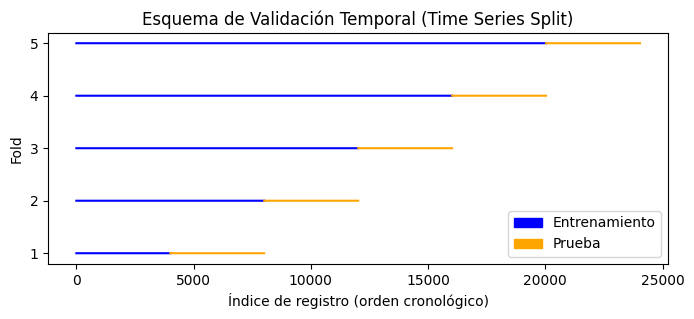

In [196]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

tscv = TimeSeriesSplit(n_splits=5)
plt.figure(figsize=(8,3))
for i, (train_idx, test_idx) in enumerate(tscv.split(df)):
    plt.plot(train_idx, [i+1]*len(train_idx), color='blue')
    plt.plot(test_idx, [i+1]*len(test_idx), color='orange')
plt.title("Esquema de Validación Temporal (Time Series Split)")
plt.xlabel("Índice de registro (orden cronológico)")
plt.ylabel("Fold")
plt.legend(handles=[Patch(color='blue', label='Entrenamiento'),
                    Patch(color='orange', label='Prueba')])
plt.show()


# **ENTRENAMIENTO DEL MODELO**

In [197]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import joblib

# COPIA DEL DATAFRAME ORIGINAL
df_modelo = df.copy()

# GUARDAR TODOS LOS LABELENCODERS
encoders = {}
label_cols = ['producto', 'tipo_producto', 'marca', 'categoria', 'metodo_pago', 'comprobante']

for col in label_cols:
    encoders[col] = LabelEncoder()
    df_modelo[col] = encoders[col].fit_transform(df_modelo[col].astype(str))

# --- Codificar cualquier columna extra tipo object ---
obj_cols = df_modelo.select_dtypes(include="object").columns.tolist()

for col in obj_cols:
    encoders[col] = LabelEncoder()
    df_modelo[col] = encoders[col].fit_transform(df_modelo[col].astype(str))

# --- Guardar encoders ---
joblib.dump(encoders, "encoders.pkl")
print("Encoders guardados en encoders.pkl")

# 3. ENTRENAMIENTO DEL MODELO
TARGET = 'cantidad'

if 'fecha' in df_modelo.columns:
    df_modelo = df_modelo.sort_values('fecha').reset_index(drop=True)

n = len(df_modelo)
test_size = int(n * 0.15)
train_df = df_modelo.iloc[:n - test_size]
test_df  = df_modelo.iloc[n - test_size:]

drop_cols = ['fecha'] if 'fecha' in df_modelo.columns else []

X_train = train_df.drop(columns=[TARGET] + drop_cols)
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET] + drop_cols)
y_test  = test_df[TARGET]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2
)

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_t, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_t, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_t, y_t)
    y_pred_val = model.predict(X_val)
    mae_scores.append(mean_absolute_error(y_val, y_pred_val))

print(f"MAE promedio validación cruzada: {np.mean(mae_scores):.4f}")

# Entrenar modelo final
model.fit(X_train, y_train)

# Evaluación Holdout
y_pred = model.predict(X_test)

def safe_mape(y_true, y_pred):
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

mae = mean_absolute_error(y_test, y_pred)
mape = safe_mape(y_test, y_pred)

print(f"MAE holdout: {mae:.4f}")
print(f"MAPE holdout: {mape:.2f}%")

# Guardar modelo
joblib.dump(model, "modelo_demanda.pkl")
print("Modelo guardado como modelo_demanda.pkl")

Encoders guardados en encoders.pkl
MAE promedio validación cruzada: 6.5958
MAE holdout: 3.3872
MAPE holdout: 16.48%
Modelo guardado como modelo_demanda.pkl


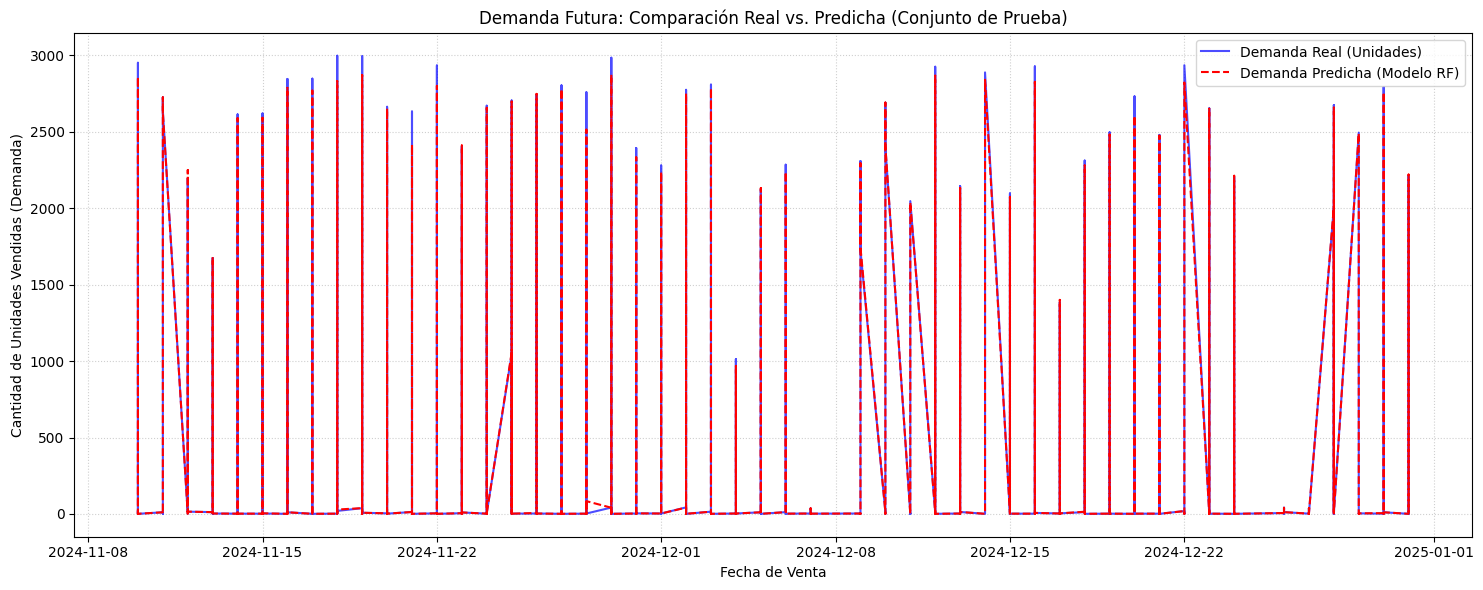


--- Conclusión Visual ---
las líneas 'Demanda Real' y 'Demanda Predicha' se superponen,
esto indica que el modelo es efectivo para predecir la demanda futura.


In [198]:
# Importar la librería de gráficos
import matplotlib.pyplot as plt

# 1. Crear un DataFrame para la comparación
# Utilizamos los índices de X_test para alinear las fechas de los datos reales y predichos
comparacion = pd.DataFrame({
    'Demanda_Real': y_test,
    'Demanda_Predicha': y_pred
}, index=X_test.index)

# 2. Re-introducir la fecha para un eje X legible

if 'fecha' in df_modelo.columns:
    # Obtener las fechas correspondientes al conjunto de prueba
    fechas_test = df_modelo.iloc[len(df_modelo) - len(y_test):]['fecha']
    comparacion.index = fechas_test.reset_index(drop=True)

# 3. Generar la gráfica
plt.figure(figsize=(15, 6))

# Graficar la demanda real
plt.plot(comparacion['Demanda_Real'], label='Demanda Real (Unidades)', color='blue', alpha=0.7)

# Graficar la demanda predicha
plt.plot(comparacion['Demanda_Predicha'], label='Demanda Predicha (Modelo RF)', color='red', linestyle='--')

plt.title('Demanda Futura: Comparación Real vs. Predicha (Conjunto de Prueba)')
plt.xlabel('Fecha de Venta')
plt.ylabel('Cantidad de Unidades Vendidas (Demanda)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- Conclusión Visual ---")
print("las líneas 'Demanda Real' y 'Demanda Predicha' se superponen,")
print("esto indica que el modelo es efectivo para predecir la demanda futura.")

MAE: 3.3872
MAPE: 16.48%
R²: 0.9986


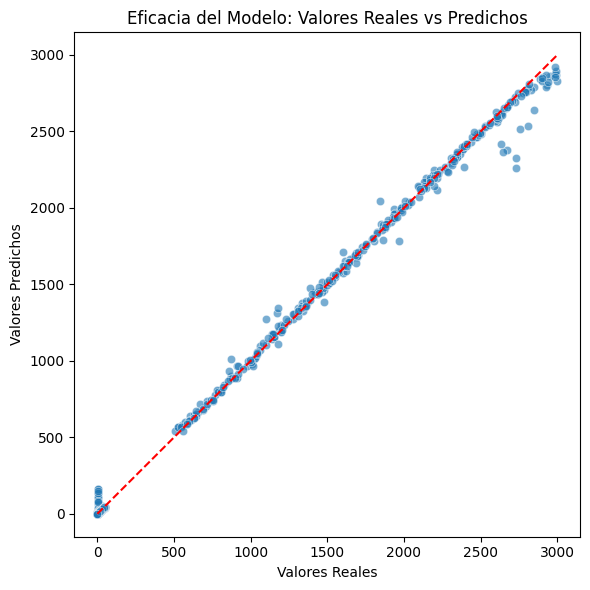

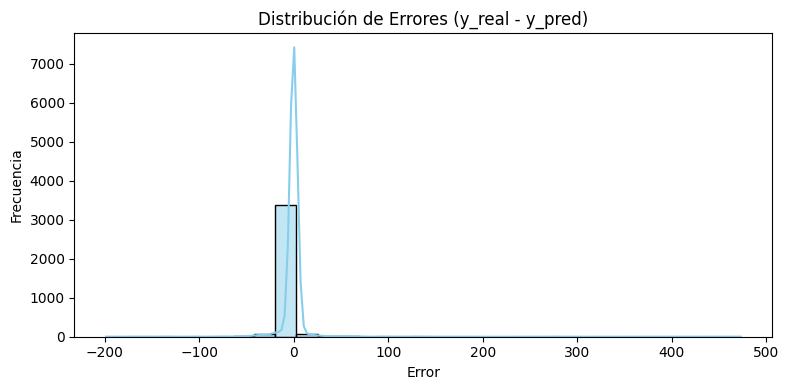

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Métricas
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / np.where(y_test == 0, 1, y_test))) * 100
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

# Gráfico 1: valores reales vs predichos
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Eficacia del Modelo: Valores Reales vs Predichos')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.tight_layout()
plt.show()

# Gráfico 2: distribución de errores
errores = y_test - y_pred
plt.figure(figsize=(8,4))
sns.histplot(errores, bins=30, kde=True, color='skyblue')
plt.title('Distribución de Errores (y_real - y_pred)')
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


# **Evaluación del Modelo**

In [200]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Resultados del Modelo")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

baseline_pred = np.mean(y_train)
baseline_mae = mean_absolute_error(y_test, [baseline_pred]*len(y_test))
print(f"\nBenchmark MAE (promedio histórico): {baseline_mae:.4f}")

Resultados del Modelo
MAE:  3.3872
RMSE: 20.1871
R²:   0.9986
MAPE: 16.48%

Benchmark MAE (promedio histórico): 290.1052


# **Interpretabilidad del Modelo**

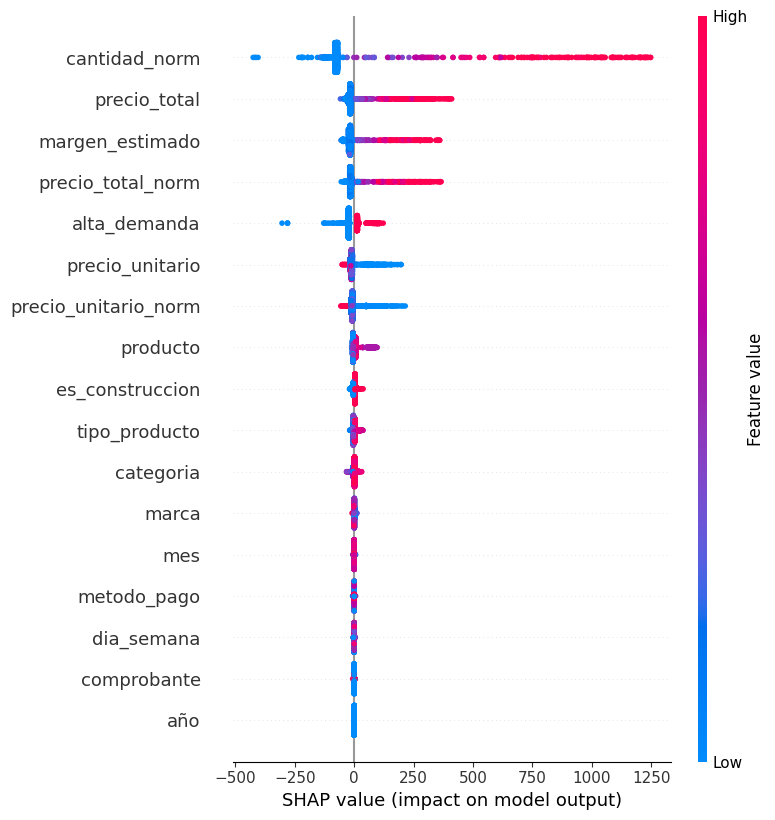


### **Interpretación — Summary Plot (Explicación Global)**  
- Este gráfico muestra **la importancia global de cada característica** del modelo Random Forest.  
- Las variables se ordenan según su influencia total en las predicciones.  
- Cada punto representa una fila del dataset.  
    - **Color rojo:** valores altos de la variable.  
    - **Color azul:** valores bajos.  
- Si los puntos rojos están hacia la derecha → valores altos **aumentan** la predicción.  
- Si los puntos azules están hacia la derecha → valores bajos **aumentan** la predicción.  
- Este gráfico sirve para conocer **qué tan dependiente es el modelo de cada variable**.


<Figure size 640x480 with 0 Axes>

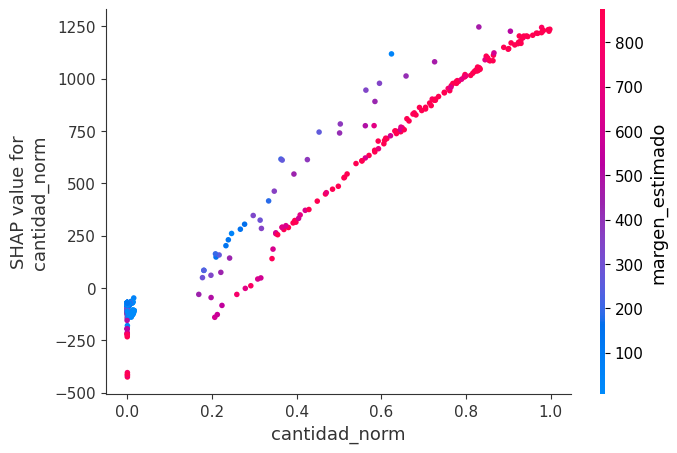


### **Interpretación — Dependence Plot (Variable: `cantidad_norm`)**  
- Muestra **cómo afecta la variable más importante** a las predicciones.  
- Cada punto es un registro del dataset.  
- El eje X muestra los valores de `cantidad_norm`.  
- El eje Y muestra su contribución SHAP (positiva o negativa).  
- Si la gráfica sube → valores mayores de `cantidad_norm` **incrementan** las predicciones.  
- Si baja → valores mayores de `cantidad_norm` **reducen** la predicción.  
- Esta gráfica permite entender la **relación directa entre una variable crítica y el resultado**.


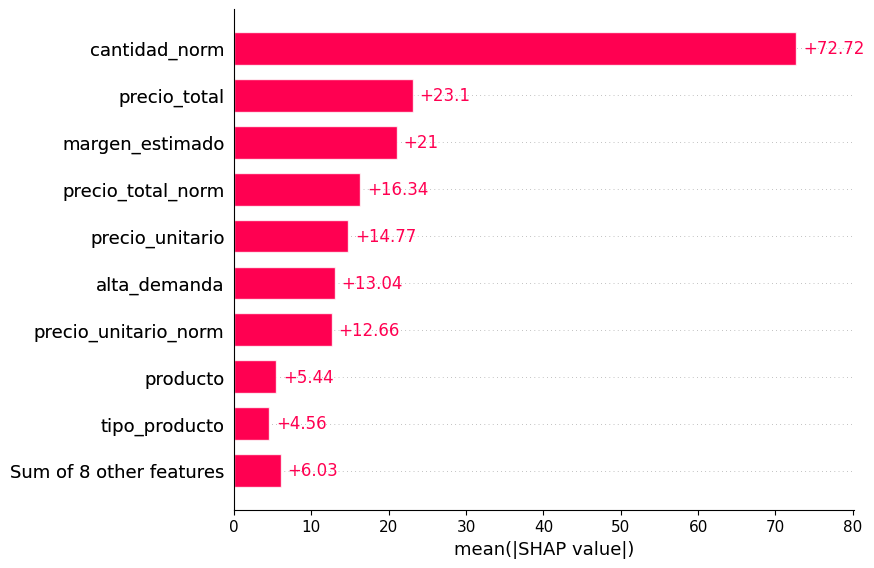


### **Interpretación — Explicación Local para el registro 0**  
- Este gráfico explica **por qué el modelo predijo ese valor específico** para esta fila del test.  
- Las barras **positivas** empujan la predicción hacia arriba.  
- Las barras **negativas** la empujan hacia abajo.  
- El **valor base** es la predicción promedio del modelo → se ajusta según las características del registro.  
- Este análisis es útil para:  
  - justificar decisiones del modelo,  
  - entender casos atípicos,  
  - validar comportamiento del modelo en escenarios reales.


In [201]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# Inicializar SHAP para visualización en el notebook
shap.initjs()

# 1. Crear explainer para RandomForest
explainer = shap.TreeExplainer(model)

# 2. Tomar una muestra para evitar alto uso de memoria
X_sample = X_train.sample(n=min(2000, len(X_train)), random_state=42)

# 3. Calcular valores SHAP
shap_values = explainer.shap_values(X_sample)

# (A) SUMMARY PLOT – Interpretación global del modelo
plt.figure()
shap.summary_plot(shap_values, X_sample, show=True)
plt.show()

display(Markdown("""
### **Interpretación — Summary Plot (Explicación Global)**  
- Este gráfico muestra **la importancia global de cada característica** del modelo Random Forest.  
- Las variables se ordenan según su influencia total en las predicciones.  
- Cada punto representa una fila del dataset.  
    - **Color rojo:** valores altos de la variable.  
    - **Color azul:** valores bajos.  
- Si los puntos rojos están hacia la derecha → valores altos **aumentan** la predicción.  
- Si los puntos azules están hacia la derecha → valores bajos **aumentan** la predicción.  
- Este gráfico sirve para conocer **qué tan dependiente es el modelo de cada variable**.
"""))

# (B) DEPENDENCE PLOT – Relación entre la variable más importante y la predicción
# encontrar la variable más influyente
top_feature = X_sample.columns[np.argmax(np.abs(np.mean(shap_values, axis=0)))]

plt.figure()
shap.dependence_plot(top_feature, shap_values, X_sample, show=True)
plt.show()

display(Markdown(f"""
### **Interpretación — Dependence Plot (Variable: `{top_feature}`)**  
- Muestra **cómo afecta la variable más importante** a las predicciones.  
- Cada punto es un registro del dataset.  
- El eje X muestra los valores de `{top_feature}`.  
- El eje Y muestra su contribución SHAP (positiva o negativa).  
- Si la gráfica sube → valores mayores de `{top_feature}` **incrementan** las predicciones.  
- Si baja → valores mayores de `{top_feature}` **reducen** la predicción.  
- Esta gráfica permite entender la **relación directa entre una variable crítica y el resultado**.
"""))

# (C) EXPLICACIÓN LOCAL – Por qué el modelo predijo un valor específico
i = 0  # índice de ejemplo
x_explain = X_test.iloc[i:i+1]

shap_vals_local = explainer.shap_values(x_explain)

shap.plots.bar(
    shap.Explanation(
        values=shap_vals_local,
        base_values=explainer.expected_value,
        data=x_explain.values,
        feature_names=X_train.columns
    )
)
plt.show()

display(Markdown(f"""
### **Interpretación — Explicación Local para el registro {i}**  
- Este gráfico explica **por qué el modelo predijo ese valor específico** para esta fila del test.  
- Las barras **positivas** empujan la predicción hacia arriba.  
- Las barras **negativas** la empujan hacia abajo.  
- El **valor base** es la predicción promedio del modelo → se ajusta según las características del registro.  
- Este análisis es útil para:  
  - justificar decisiones del modelo,  
  - entender casos atípicos,  
  - validar comportamiento del modelo en escenarios reales.
"""))

In [202]:
print("Columnas usadas por el modelo:")
list(X_train.columns)

Columnas usadas por el modelo:


['producto',
 'tipo_producto',
 'marca',
 'categoria',
 'precio_unitario',
 'precio_total',
 'metodo_pago',
 'comprobante',
 'cantidad_norm',
 'precio_unitario_norm',
 'precio_total_norm',
 'mes',
 'año',
 'dia_semana',
 'es_construccion',
 'margen_estimado',
 'alta_demanda']

In [203]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24038 entries, 0 to 24037
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 23334 non-null  datetime64[ns]
 1   producto              24038 non-null  object        
 2   tipo_producto         24038 non-null  object        
 3   marca                 24038 non-null  object        
 4   categoria             24038 non-null  object        
 5   cantidad              24038 non-null  float64       
 6   precio_unitario       24038 non-null  float64       
 7   precio_total          24038 non-null  float64       
 8   metodo_pago           24038 non-null  object        
 9   comprobante           24038 non-null  object        
 10  cantidad_norm         24038 non-null  float64       
 11  precio_unitario_norm  24038 non-null  float64       
 12  precio_total_norm     24038 non-null  float64       
 13  mes             

,fecha,producto,tipo_producto,marca,categoria,cantidad,precio_unitario,precio_total,metodo_pago,comprobante,cantidad_norm,precio_unitario_norm,precio_total_norm,mes,año,dia_semana,es_construccion,margen_estimado,alta_demanda
0,2024-01-02,grava,no especificado,ladrillera virú,material_construccion,3.0,36.86,110.58,yape,boleta,0.000667,0.019374,0.010713,1.0,2024.0,Martes,1,33.174,0
1,2024-01-02,arena,fina,ladrillera virú,material_construccion,1.0,67.87,67.87,efectivo,factura,0.000000,0.035695,0.006514,1.0,2024.0,Martes,1,20.361,0
2,2024-01-02,destornillador,plano 6mm,stanley,herramientas,1.0,53.08,53.08,efectivo,factura,0.000000,0.027911,0.005060,1.0,2024.0,Martes,0,15.924,0
3,2024-01-02,ladrillo,techo,cerámica lark,material_construccion,1590.0,3.27,5199.30,tarjeta,factura,0.530197,0.001695,0.511040,1.0,2024.0,Martes,1,1559.790,1
4,2024-01-02,rodillo,mini,pintuco,pinturas,1.0,38.62,38.62,plin,factura,0.000000,0.020300,0.003638,1.0,2024.0,Martes,0,11.586,0


In [204]:
df_modelo['mes'] = df_modelo['mes'].fillna(df_modelo['mes'].mode()[0])
df_modelo['año'] = df_modelo['año'].fillna(df_modelo['año'].mode()[0])
df_modelo['dia_semana'] = df_modelo['dia_semana'].fillna(df_modelo['dia_semana'].mode()[0])

In [205]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24038 entries, 0 to 24037
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 23334 non-null  datetime64[ns]
 1   producto              24038 non-null  int64         
 2   tipo_producto         24038 non-null  int64         
 3   marca                 24038 non-null  int64         
 4   categoria             24038 non-null  int64         
 5   cantidad              24038 non-null  float64       
 6   precio_unitario       24038 non-null  float64       
 7   precio_total          24038 non-null  float64       
 8   metodo_pago           24038 non-null  int64         
 9   comprobante           24038 non-null  int64         
 10  cantidad_norm         24038 non-null  float64       
 11  precio_unitario_norm  24038 non-null  float64       
 12  precio_total_norm     24038 non-null  float64       
 13  mes             

In [206]:
def limpieza_profunda_modelo(df_modelo):

    df = df_modelo.copy()

    # ============================
    # 1. ESTANDARIZAR TEXTO
    # ============================
    columnas_objeto = df.select_dtypes(include=["object"]).columns

    for col in columnas_objeto:
        df[col] = df[col].astype(str).str.strip().str.lower()

    # ============================
    # 2. REEMPLAZOS GENERALES
    # ============================
    valores_nulos = [
        "nan", "none", "null", "n/a", "na", "undefined", "",
        "desconocida", "desconocido", "sin marca", "sin_marca",
        "no definido", "nulo", "vacío"
    ]

    for col in columnas_objeto:
        df[col] = df[col].replace(valores_nulos, np.nan)

    # ============================
    # 3. CORRECCIÓN PARA MARCA
    # ============================
    # Relleno general
    df["marca"] = df["marca"].fillna("sin_marca")

    # Corrección específica para cemento
    df.loc[
        (df["producto"] == "cemento") & (df["marca"] == "unacem"),
        "marca"
    ] = "cemento andino"

    # Convertir "cementos inka" a formato estándar si aparece como variación
    df["marca"] = df["marca"].replace({
        "inka": "cementos inka",
        "cemento inka": "cementos inka"
    })

    # ============================
    # 4. CORRECCIÓN PARA PRODUCTOS
    # ============================
    df["producto"] = df["producto"].fillna("sin_producto")

    # ============================
    # 5. ELIMINAR FILAS BASURA
    # ============================
    condiciones_basura = (
        (df["cantidad"] <= 0) |
        (df["precio_unitario"] <= 0) |
        (df["precio_total"] <= 0) |
        (df["producto"] == "sin_producto")
    )

    df = df[~condiciones_basura]

    # Eliminar filas con 40%+ de nulos
    limite = int(df.shape[1] * 0.4)
    df = df[df.isnull().sum(axis=1) < limite]

    # ============================
    # 6. RECONSTRUIR CAMPOS FALTANTES
    # ============================
    # Llenado inteligente para categóricas
    for col in columnas_objeto:
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Llenado inteligente numéricas
    columnas_num = df.select_dtypes(include=[np.number]).columns
    for col in columnas_num:
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    # ============================
    # 7. LIMPIEZA DE TEXTO FINAL
    # ============================
    for col in columnas_objeto:
        df[col] = df[col].str.strip().str.lower()

    # Homogeneizar marca
    df["marca"] = df["marca"].replace("sin marca", "sin_marca")

    return df


In [207]:
df_limpio = limpieza_profunda_modelo(df)
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23316 entries, 0 to 24037
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 22637 non-null  datetime64[ns]
 1   producto              23316 non-null  object        
 2   tipo_producto         23316 non-null  object        
 3   marca                 23316 non-null  object        
 4   categoria             23316 non-null  object        
 5   cantidad              23316 non-null  float64       
 6   precio_unitario       23316 non-null  float64       
 7   precio_total          23316 non-null  float64       
 8   metodo_pago           23316 non-null  object        
 9   comprobante           23316 non-null  object        
 10  cantidad_norm         23316 non-null  float64       
 11  precio_unitario_norm  23316 non-null  float64       
 12  precio_total_norm     23316 non-null  float64       
 13  mes                  

In [162]:
model = joblib.load("modelo_demanda.pkl")
encoders = joblib.load("encoders.pkl")

In [208]:
import unicodedata

def limpiar_texto(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()

    # eliminar tildes
    x = ''.join(c for c in unicodedata.normalize('NFD', x)
                if unicodedata.category(c) != 'Mn')

    # limpiar caracteres raros
    x = x.replace("\n", "").replace("\t", "").replace("\r", "").strip()

    return x


def limpieza_profunda_modelo(df_modelo):

    df = df_modelo.copy()

    # ============================
    # 1. NORMALIZAR TODO EL TEXTO
    # ============================
    for col in df.select_dtypes(include="object"):
        df[col] = df[col].apply(limpiar_texto)

    # ============================
    # 2. REEMPLAZOS DE NULOS
    # ============================
    valores_nulos = [
        "nan","none","null","n/a","na","undefined","",
        "desconocida","desconocido","sin marca","sin_marca",
        "no definido","nd","nulo","vacio"," "
    ]

    for col in df.select_dtypes(include="object"):
        df[col] = df[col].replace(valores_nulos, np.nan)

    # ============================
    # 3. CORRECCIONES DE MARCA
    # ============================

    # Corrección de variaciones comunes
    df["marca"] = df["marca"].replace({
        "unacem": "cemento andino",
        "unacemm": "cemento andino",
        "unacen": "cemento andino",
        "unamen": "cemento andino",       # la que te aparece
        "cemenos inka": "cementos inka",
        "inka": "cementos inka",
        "cemento inka": "cementos inka",
        "inkas": "cementos inka",
        "desconocida": np.nan,
        "desconocido": np.nan
    })

    # Corrección por producto
    df.loc[
        (df["producto"] == "cemento") & (df["marca"].isna()),
        "marca"
    ] = "sin_marca"

    # ============================
    # 4. VALIDACIÓN FINAL: limpiar basura
    # ============================
    df = df[df["producto"].notna()]
    df = df[df["marca"].notna()]

    # Reemplazo final
    df["marca"] = df["marca"].fillna("sin_marca")

    return df

In [209]:
def predecir_demanda_simple(producto, mes, año, precio_unitario):
    """
    Predicción simplificada de la demanda solo con:
    - producto (texto)
    - mes
    - año
    - precio_unitario
    """

    # Función interna para limpiar np.float64 / np.int64
    def limpiar_valor(v):
        if hasattr(v, "item"):   # convierte np.* a tipos nativos
            return v.item()
        return v

    # 1. Buscar información histórica del producto 
    df_prod = df[df["producto"] == producto]

    if df_prod.empty:
        raise ValueError(f"El producto '{producto}' no existe en los datos.")

    # Usar valores típicos del producto
    tipo_producto = df_prod["tipo_producto"].mode()[0]
    marca = df_prod["marca"].mode()[0]
    categoria = df_prod["categoria"].mode()[0]
    metodo_pago = df_prod["metodo_pago"].mode()[0]
    comprobante = df_prod["comprobante"].mode()[0]

    # Valores normalizados típicos
    cantidad_norm = df_prod["cantidad_norm"].mean()
    precio_unitario_norm = df_prod["precio_unitario_norm"].mean()
    precio_total_norm = df_prod["precio_total_norm"].mean()

    # Precio total (asumiendo venta de 2 unidades)
    precio_total = precio_unitario * 2

    # Variables del negocio
    es_construccion = int("CONSTRU" in tipo_producto.upper())
    margen_estimado = df_prod["margen_estimado"].mean()
    alta_demanda = df_prod["alta_demanda"].mode()[0]

    # Día de la semana: suponemos lunes
    dia_semana = "Lunes"

    # 2. Armar DataFrame con columnas del modelo
    data = {
        "producto": [encoders["producto"].transform([producto])[0]],
        "tipo_producto": [encoders["tipo_producto"].transform([tipo_producto])[0]],
        "marca": [encoders["marca"].transform([marca])[0]],
        "categoria": [encoders["categoria"].transform([categoria])[0]],
        "precio_unitario": [precio_unitario],
        "precio_total": [precio_total],
        "metodo_pago": [encoders["metodo_pago"].transform([metodo_pago])[0]],
        "comprobante": [encoders["comprobante"].transform([comprobante])[0]],
        "cantidad_norm": [cantidad_norm],
        "precio_unitario_norm": [precio_unitario_norm],
        "precio_total_norm": [precio_total_norm],
        "mes": [mes],
        "año": [año],
        "dia_semana": [encoders["dia_semana"].transform([dia_semana])[0]],
        "es_construccion": [es_construccion],
        "margen_estimado": [margen_estimado],
        "alta_demanda": [alta_demanda],
    }

    df_input = pd.DataFrame(data)

    # 3. Predicción
    pred = model.predict(df_input)[0]

    # 4. Resultado limpio con tipos normales
    resultado_bruto = {
        "producto": producto,
        "demanda_estimado": round(pred, 2),
        "precio_usado": precio_unitario,
        "mes": mes,
        "año": año
    }

    # Convertir numpy → tipos Python estándar
    resultado = {k: limpiar_valor(v) for k, v in resultado_bruto.items()}

    return resultado


In [210]:
PRODUCTOS_DISPONIBLES = df["producto"].unique().tolist()
print(PRODUCTOS_DISPONIBLES)


['grava', 'arena', 'destornillador', 'ladrillo', 'rodillo', 'sellador_silicon', 'adhesivo', 'fierro_corrugado', 'valvula', 'cemento', 'pintura', 'manguera', 'tuercas_arandelas', 'cintillos', 'brocha', 'escalera', 'caja_placa', 'calamina', 'nan', 'wincha', 'cortadora_ladrillo', 'cinta_teflon', 'soldador_inverter', 'enchufe', 'taladro', 'grifos', 'interruptor', 'caja_herramientas', 'disolvente', 'tornillos', 'pegamento_contacto', 'casco', 'candado', 'malla_mosquitera', 'led_tira', 'sellador_termico', 'martillo', 'tarugos', 'llave_inglesa', 'serrucho', 'thinner', 'clavos', 'juego_llaves_dados', 'arnes', 'sierra_circular', 'lija', 'cable', 'tuberia_pvc', 'pernos_bulones', 'aspersor_jardin', 'sellador', 'llave_tubo', 'nivel_burbuja', 'tomacorriente', 'guantes', 'foco_led', 'alicate']


In [211]:
resultado = predecir_demanda_simple(
    producto="grava",
    mes=11,
    año=2024,
    precio_unitario=27.5
)

resultado

{'producto': 'grava',
 'demanda_estimado': 2.1,
 'precio_usado': 27.5,
 'mes': 11,
 'año': 2024}

In [212]:
def predecir_demanda_futura_producto(producto, año_proximo=2025):
    """
    Predice la demanda mensual futura del próximo año para un producto.
    Solo requiere el nombre del producto.
    """

    # 1. Validar producto
    df_prod = df[df["producto"] == producto]

    if df_prod.empty:
        raise ValueError(f"El producto '{producto}' no existe en los datos.")

    # 2. Extraer valores históricos típicos del producto
    tipo_producto = df_prod["tipo_producto"].mode()[0]
    marca = df_prod["marca"].mode()[0]
    categoria = df_prod["categoria"].mode()[0]
    metodo_pago = df_prod["metodo_pago"].mode()[0]
    comprobante = df_prod["comprobante"].mode()[0]

    cantidad_norm = df_prod["cantidad_norm"].mean()
    precio_unitario_norm = df_prod["precio_unitario_norm"].mean()
    precio_total_norm = df_prod["precio_total_norm"].mean()

    # Precio promedio real
    precio_unitario_promedio = df_prod["precio_unitario"].mean()

    es_construccion = int("CONSTRU" in tipo_producto.upper())
    margen_estimado = df_prod["margen_estimado"].mean()
    alta_demanda = df_prod["alta_demanda"].mode()[0]

    dia_semana = "Lunes"  # suposición

    # 3. Preparar predicciones mensuales
    resultados = []

    for mes in range(1, 13):

        precio_total = precio_unitario_promedio * 2  # misma regla anterior

        data = {
            "producto": [encoders["producto"].transform([producto])[0]],
            "tipo_producto": [encoders["tipo_producto"].transform([tipo_producto])[0]],
            "marca": [encoders["marca"].transform([marca])[0]],
            "categoria": [encoders["categoria"].transform([categoria])[0]],
            "precio_unitario": [precio_unitario_promedio],
            "precio_total": [precio_total],
            "metodo_pago": [encoders["metodo_pago"].transform([metodo_pago])[0]],
            "comprobante": [encoders["comprobante"].transform([comprobante])[0]],
            "cantidad_norm": [cantidad_norm],
            "precio_unitario_norm": [precio_unitario_norm],
            "precio_total_norm": [precio_total_norm],
            "mes": [mes],
            "año": [año_proximo],
            "dia_semana": [encoders["dia_semana"].transform([dia_semana])[0]],
            "es_construccion": [es_construccion],
            "margen_estimado": [margen_estimado],
            "alta_demanda": [alta_demanda],
        }

        df_input = pd.DataFrame(data)
        pred = float(model.predict(df_input)[0])

        resultados.append({
            "producto": producto,
            "año": año_proximo,
            "mes": mes,
            "demanda_estimado": round(pred, 2),
            "precio_usado": round(precio_unitario_promedio, 2)
        })

    return pd.DataFrame(resultados)

In [213]:
df_predicciones = predecir_demanda_futura_producto("wincha")
df_predicciones

,producto,año,mes,demanda_estimado,precio_usado
0,wincha,2025,1,2.03,29.37
1,wincha,2025,2,2.03,29.37
2,wincha,2025,3,2.03,29.37
3,wincha,2025,4,2.03,29.37
4,wincha,2025,5,2.03,29.37
5,wincha,2025,6,2.03,29.37
6,wincha,2025,7,2.03,29.37
7,wincha,2025,8,2.02,29.37
8,wincha,2025,9,2.02,29.37
9,wincha,2025,10,2.02,29.37


In [219]:
def predecir_demanda_futura_por_marca(producto, año_proximo=2025):
    """
    Predice la demanda futura (12 meses del próximo año) 
    para cada marca asociada a un producto.
    """

    # 1. Filtrar historial del producto
    df_prod = df[df["producto"] == producto]

    if df_prod.empty:
        raise ValueError(f"El producto '{producto}' no existe en los datos.")

    # Obtener todas las marcas asociadas al producto
    marcas = df_prod["marca"].unique()

    resultados = []

    for marca in marcas:

        df_marca = df_prod[df_prod["marca"] == marca]

        # Valores históricos típicos por marca
        tipo_producto = df_marca["tipo_producto"].mode()[0]
        categoria = df_marca["categoria"].mode()[0]
        metodo_pago = df_marca["metodo_pago"].mode()[0]
        comprobante = df_marca["comprobante"].mode()[0]

        cantidad_norm = df_marca["cantidad_norm"].mean()
        precio_unitario_norm = df_marca["precio_unitario_norm"].mean()
        precio_total_norm = df_marca["precio_total_norm"].mean()

        # Precio promedio real
        precio_unitario_promedio = df_marca["precio_unitario"].mean()
        precio_total = precio_unitario_promedio * 2

        es_construccion = int("CONSTRU" in tipo_producto.upper())
        margen_estimado = df_marca["margen_estimado"].mean()
        alta_demanda = df_marca["alta_demanda"].mode()[0]

        dia_semana = "Lunes"

        # Generar predicciones para los 12 meses
        for mes in range(1, 13):

            data = {
                "producto": [encoders["producto"].transform([producto])[0]],
                "tipo_producto": [encoders["tipo_producto"].transform([tipo_producto])[0]],
                "marca": [encoders["marca"].transform([marca])[0]],
                "categoria": [encoders["categoria"].transform([categoria])[0]],
                "precio_unitario": [precio_unitario_promedio],
                "precio_total": [precio_total],
                "metodo_pago": [encoders["metodo_pago"].transform([metodo_pago])[0]],
                "comprobante": [encoders["comprobante"].transform([comprobante])[0]],
                "cantidad_norm": [cantidad_norm],
                "precio_unitario_norm": [precio_unitario_norm],
                "precio_total_norm": [precio_total_norm],
                "mes": [mes],
                "año": [año_proximo],
                "dia_semana": [encoders["dia_semana"].transform([dia_semana])[0]],
                "es_construccion": [es_construccion],
                "margen_estimado": [margen_estimado],
                "alta_demanda": [alta_demanda],
            }

            df_input = pd.DataFrame(data)
            pred = float(model.predict(df_input)[0])

            resultados.append({
                "producto": producto,
                "marca": marca,
                "año": año_proximo,
                "mes": mes,
                "demanda_estimado": round(pred, 2),
                "precio_usado": round(precio_unitario_promedio, 2)
            })

    return pd.DataFrame(resultados)

In [220]:
df_marcas_pred = predecir_demanda_futura_por_marca("ladrillo")
df_marcas_pred

,producto,marca,año,mes,demanda_estimado,precio_usado
0,ladrillo,cerámica lark,2025,1,1485.68,3.74
1,ladrillo,cerámica lark,2025,2,1483.04,3.74
2,ladrillo,cerámica lark,2025,3,1472.04,3.74
3,ladrillo,cerámica lark,2025,4,1472.38,3.74
4,ladrillo,cerámica lark,2025,5,1469.17,3.74
5,ladrillo,cerámica lark,2025,6,1466.74,3.74
6,ladrillo,cerámica lark,2025,7,1467.91,3.74
7,ladrillo,cerámica lark,2025,8,1460.54,3.74
8,ladrillo,cerámica lark,2025,9,1452.77,3.74
9,ladrillo,cerámica lark,2025,10,1437.25,3.74
